# Sprint 3 - US28 to US31

Regression Analysis for Transparency Assessment

## US28

**To be developed**

In [20]:
# Your solution here

## US29

**Descrição:**  
Como membro do Comité de Ética, pretende-se estabelecer uma relação esperada entre o rendimento total declarado e o património total declarado dos agentes políticos, de forma a identificar casos potencialmente anómalos de acumulação de riqueza.

Nesta análise são consideradas apenas as declarações mais recentes de cada agente.

---

## Conceitos Teóricos Aplicados

### Rendimento Total

O rendimento total declarado é calculado como:

\[
\text{total\_income} = \text{gross\_salary} + \sum \text{side\_income}
\]

### Património Total Declarado

O património total declarado é calculado como:

\[
\text{total\_assets} =
\text{assets\_in\_real\_estate}
+
\text{assets\_in\_vehicles}
+
\text{assets\_in\_stocks}
\]

### Regressão Linear Simples

Pretende-se modelar a relação entre rendimento total e património total através de uma reta:

\[
\hat{y} = \hat{\beta}_0 + \hat{\beta}_1x
\]

onde:

- \(x\) representa o rendimento total;
- \(y\) representa o património total;
- \(\hat{y}\) representa o património esperado segundo o modelo.

### Resíduo

O resíduo mede o desvio entre o valor observado e o valor esperado:

\[
e_i = y_i - \hat{y}_i
\]

Um resíduo positivo elevado indica que o agente tem mais património declarado do que seria esperado para o seu rendimento.

### Outliers

Para identificar outliers nos resíduos, é usado o critério do intervalo interquartil:

\[
\text{Limite Superior} = Q3 + 1.5 \times IQR
\]

Agentes com resíduos acima deste limite são considerados outliers superiores, ou seja, casos com possível acumulação patrimonial anormal.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

def load_declarations_data_us29(path: str) -> pd.DataFrame:
    """Load and prepare the declarations dataset for US29."""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df["declaration_date"] = pd.to_datetime(df["declaration_date"])

    return df


DATA_PATH = "../Dados/dataset1_declarations.csv"

df = load_declarations_data_us29(DATA_PATH)

print(f"Dataset carregado: {df.shape[0]} declarações")
print(f"Agentes únicos   : {df['agent_id'].nunique()}")
print(f"Período          : {df['declaration_date'].min().date()} a {df['declaration_date'].max().date()}")


# ── Preparação dos dados ─────────────────────────────────────────────────────

def get_most_recent_declarations(df: pd.DataFrame) -> pd.DataFrame:
    """Return only the most recent declaration for each agent."""
    latest_df = (
        df.sort_values("declaration_date")
          .groupby("agent_id", as_index=False)
          .tail(1)
          .reset_index(drop=True)
    )

    return latest_df


def calculate_total_income_and_assets(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate total income and total declared assets."""

    side_income_cols = [col for col in df.columns if col.startswith("side_income_")]

    required_asset_cols = [
        "assets_in_real_estate",
        "assets_in_vehicles",
        "assets_in_stocks"
    ]

    missing_assets = [col for col in required_asset_cols if col not in df.columns]
    if missing_assets:
        raise ValueError(f"Colunas de ativos em falta: {missing_assets}")

    df = df.copy()

    df["total_side_income"] = df[side_income_cols].sum(axis=1)
    df["total_income"] = df["gross_salary"] + df["total_side_income"]
    df["total_assets"] = df[required_asset_cols].sum(axis=1)

    return df


# ── Regressão linear simples, estilo MATCP ───────────────────────────────────

def fit_simple_linear_regression(df: pd.DataFrame):
    """Estimate the simple linear regression manually using least squares."""

    x = df["total_income"].to_numpy()
    y = df["total_assets"].to_numpy()

    x_mean = x.mean()
    y_mean = y.mean()

    sxx = np.sum((x - x_mean) ** 2)
    sxy = np.sum((x - x_mean) * (y - y_mean))
    syy = np.sum((y - y_mean) ** 2)

    beta_1 = sxy / sxx
    beta_0 = y_mean - beta_1 * x_mean

    y_pred = beta_0 + beta_1 * x
    residuals = y - y_pred

    r = sxy / np.sqrt(sxx * syy)
    r_squared = r ** 2

    return beta_0, beta_1, y_pred, residuals, r, r_squared


def add_regression_results(df: pd.DataFrame) -> pd.DataFrame:
    """Add predicted assets, residuals and absolute residuals to dataframe."""

    result_df = df.copy()

    beta_0, beta_1, y_pred, residuals, r, r_squared = fit_simple_linear_regression(result_df)

    result_df["expected_assets"] = y_pred
    result_df["residual"] = residuals
    result_df["abs_residual"] = np.abs(residuals)

    return result_df, beta_0, beta_1, r, r_squared


# ── Outliers ─────────────────────────────────────────────────────────────────

def classify_residual_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """Classify positive residual outliers using the IQR rule."""

    result_df = df.copy()

    q1 = result_df["residual"].quantile(0.25)
    q3 = result_df["residual"].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    result_df["is_upper_outlier"] = result_df["residual"] > upper_limit
    result_df["is_lower_outlier"] = result_df["residual"] < lower_limit
    result_df["is_outlier"] = result_df["is_upper_outlier"] | result_df["is_lower_outlier"]

    return result_df, q1, q3, iqr, lower_limit, upper_limit


def get_top_10_positive_deviations(df: pd.DataFrame) -> pd.DataFrame:
    """Return the 10 agents with the largest positive residuals."""

    return (
        df.sort_values("residual", ascending=False)
          .head(10)
          .reset_index(drop=True)
    )

Dataset carregado: 13395 declarações
Agentes únicos   : 2364
Período          : 2018-01-01 a 2026-03-30


In [22]:
# ── 1. Declaração mais recente por agente ────────────────────────────────────
recent_df = get_most_recent_declarations(df)
recent_df = calculate_total_income_and_assets(recent_df)

print(f"Agentes analisados (declaração mais recente): {len(recent_df)}")
print(f"\nEstatísticas — Rendimento Total (total_income):")
print(recent_df["total_income"].describe().map(lambda x: f"{x:,.2f}€"))
print(f"\nEstatísticas — Património Total (total_assets):")
print(recent_df["total_assets"].describe().map(lambda x: f"{x:,.2f}€"))

# ── 2. Regressão linear e resíduos ───────────────────────────────────────────
result_df, beta_0, beta_1, r, r_squared = add_regression_results(recent_df)
result_df, q1_res, q3_res, iqr_res, lower_limit, upper_limit = classify_residual_outliers(result_df)

print(f"\n{'='*70}")
print("MODELO DE REGRESSÃO LINEAR")
print(f"{'='*70}")
print(f"  Equação : Total_Assets = {beta_0:,.2f} + {beta_1:.6f} × Total_Income")
print(f"  Pearson r   : {r:.4f}")
print(f"  R²          : {r_squared:.4f}")

Agentes analisados (declaração mais recente): 2364

Estatísticas — Rendimento Total (total_income):
count      2,364.00€
mean      99,881.31€
std       31,752.98€
min       23,350.01€
25%       77,999.04€
50%       95,737.34€
75%      117,043.41€
max      256,420.37€
Name: total_income, dtype: str

Estatísticas — Património Total (total_assets):
count      2,364.00€
mean      59,372.53€
std       34,487.56€
min        1,772.46€
25%       34,065.46€
50%       53,688.64€
75%       77,556.55€
max      243,899.57€
Name: total_assets, dtype: str

MODELO DE REGRESSÃO LINEAR
  Equação : Total_Assets = 56,546.27 + 0.028296 × Total_Income
  Pearson r   : 0.0261
  R²          : 0.0007


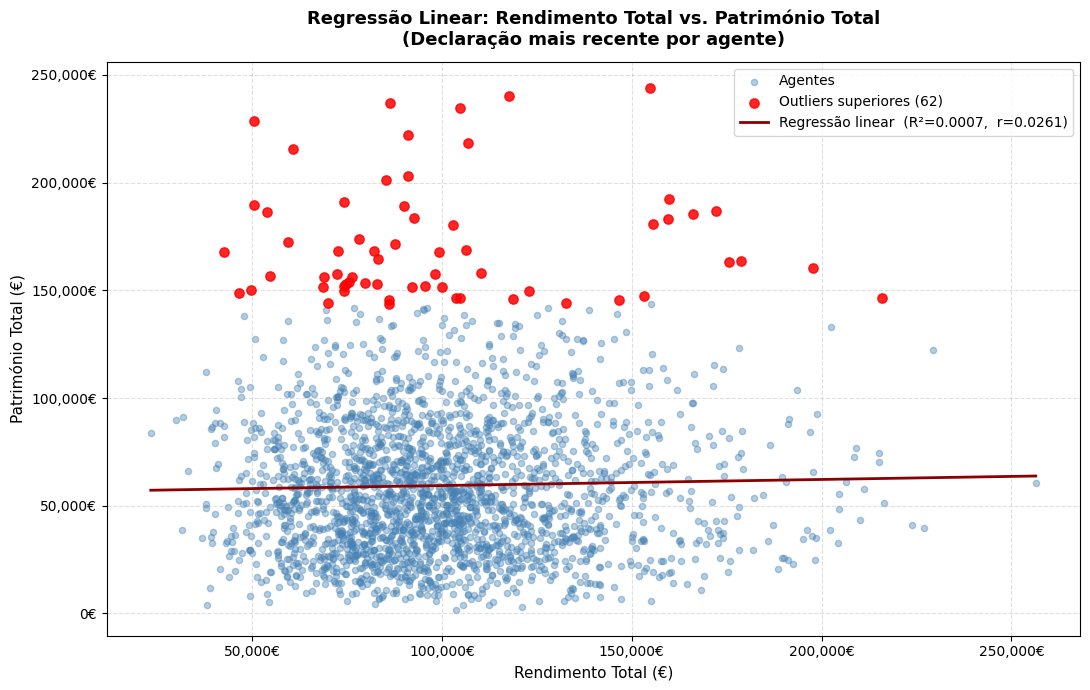

Gráfico guardado: US29_regressao_rendimento_patrimonio.svg


In [23]:
# ── 3. Scatter plot com reta de regressão ────────────────────────────────────
normal_pts  = result_df[~result_df["is_upper_outlier"]]
outlier_pts = result_df[result_df["is_upper_outlier"]]

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(normal_pts["total_income"], normal_pts["total_assets"],
           alpha=0.4, color="steelblue", s=20, label="Agentes")
ax.scatter(outlier_pts["total_income"], outlier_pts["total_assets"],
           alpha=0.85, color="red", s=45, zorder=5,
           label=f"Outliers superiores ({len(outlier_pts)})")

x_range = np.linspace(result_df["total_income"].min(),
                      result_df["total_income"].max(), 300)
ax.plot(x_range, beta_0 + beta_1 * x_range,
        color="darkred", linewidth=2,
        label=f"Regressão linear  (R²={r_squared:.4f},  r={r:.4f})")

ax.set_title(
    "Regressão Linear: Rendimento Total vs. Património Total\n"
    "(Declaração mais recente por agente)",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Rendimento Total (€)", fontsize=11)
ax.set_ylabel("Património Total (€)", fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("US29_regressao_rendimento_patrimonio.svg", format="svg", bbox_inches="tight")
plt.show()
print("Gráfico guardado: US29_regressao_rendimento_patrimonio.svg")

In [24]:
# ── 4. Top 10 agentes com maior desvio positivo ──────────────────────────────
top10 = get_top_10_positive_deviations(result_df)

print(f"{'='*100}")
print("TOP 10 — AGENTES COM MAIOR DESVIO POSITIVO  (Possível Acumulação Patrimonial Anómala)")
print(f"{'='*100}")

display_cols = ["agent_id", "role", "total_income", "expected_assets", "total_assets", "residual", "is_outlier"]
top10_display = top10[display_cols].copy()
top10_display.index = range(1, 11)

for col in ["total_income", "expected_assets", "total_assets", "residual"]:
    top10_display[col] = top10_display[col].map(lambda x: f"{x:,.2f}€")
top10_display["is_outlier"] = top10_display["is_outlier"].map({True: "Sim ✓", False: "Não"})
top10_display.columns = [
    "Agente", "Cargo",
    "Rendimento Total", "Património Esperado", "Património Real",
    "Desvio (Resíduo)", "Outlier?"
]

print(top10_display.to_string())

# ── 5. Análise de outliers nos resíduos ──────────────────────────────────────
n_upper = int(result_df["is_upper_outlier"].sum())
n_lower = int(result_df["is_lower_outlier"].sum())
n_total = int(result_df["is_outlier"].sum())

print(f"\n{'='*70}")
print("ANÁLISE DE OUTLIERS NOS RESÍDUOS  (Critério IQR)")
print(f"{'='*70}")
print(f"  Q1 dos resíduos    : {q1_res:>15,.2f}€")
print(f"  Q3 dos resíduos    : {q3_res:>15,.2f}€")
print(f"  IQR                : {iqr_res:>15,.2f}€")
print(f"  Limite inferior    : {lower_limit:>15,.2f}€   (Q1 − 1.5×IQR)")
print(f"  Limite superior    : {upper_limit:>15,.2f}€   (Q3 + 1.5×IQR)")
print()
print(f"  Outliers superiores (ativos >> esperado) : {n_upper:>4} agentes")
print(f"  Outliers inferiores (ativos << esperado) : {n_lower:>4} agentes")
print(f"  Total de outliers                        : {n_total:>4} agentes  ({100*n_total/len(result_df):.1f}% do total)")

TOP 10 — AGENTES COM MAIOR DESVIO POSITIVO  (Possível Acumulação Patrimonial Anómala)
    Agente    Cargo Rendimento Total Património Esperado Património Real Desvio (Resíduo) Outlier?
1   A01034    Judge      154,754.32€          60,925.22€     243,899.57€      182,974.35€    Sim ✓
2   A00236       MP      117,706.35€          59,876.91€     240,380.11€      180,503.20€    Sim ✓
3   A01884    Judge       86,245.65€          58,986.69€     236,889.95€      177,903.26€    Sim ✓
4   A00070       MP      104,668.16€          59,507.98€     234,798.88€      175,290.90€    Sim ✓
5   A02341  Advisor       50,560.23€          57,976.93€     228,787.33€      170,810.40€    Sim ✓
6   A01300    Judge       91,219.13€          59,127.42€     222,172.95€      163,045.52€    Sim ✓
7   A01715    Judge      107,023.38€          59,574.62€     218,486.03€      158,911.41€    Sim ✓
8   A01000    Judge       60,678.17€          58,263.23€     215,388.39€      157,125.16€    Sim ✓
9   A00431    Judge    

### Conclusão US29

O modelo de regressão linear permite estabelecer uma relação esperada entre o rendimento total declarado e o património total declarado dos agentes políticos. O coeficiente de Pearson e o R² indicam o grau em que o rendimento explica o nível patrimonial.

Os agentes com resíduos positivos elevados — isto é, cujo património declarado supera significativamente o valor esperado para o seu rendimento — são os casos de maior interesse para o Comité de Ética. O critério IQR permite identificar formalmente quais destes desvios são estatisticamente anómalos (outliers superiores), sinalizando potencial acumulação patrimonial não explicada pelos rendimentos declarados.

Os 10 agentes listados representam os casos prioritários a investigar, devendo o Comité analisar se existem fontes de rendimento ou herança não declaradas que justifiquem essa diferença.

## US30

Neste exercício foi aplicada uma regressão linear para estudar a relação entre o rendimento total declarado (salário e rendimentos adicionais) e o património total declarado pelos agentes políticos. Com base nas declarações mais recentes de cada agente, foram calculados os resíduos do modelo, correspondentes à diferença entre os valores observados e os valores previstos pela regressão. Posteriormente, foi analisada a distribuição dos resíduos nos dados originais e após a normalização das variáveis.


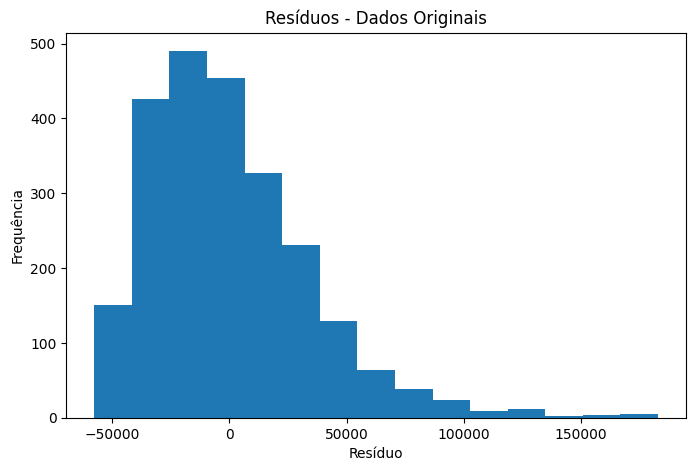

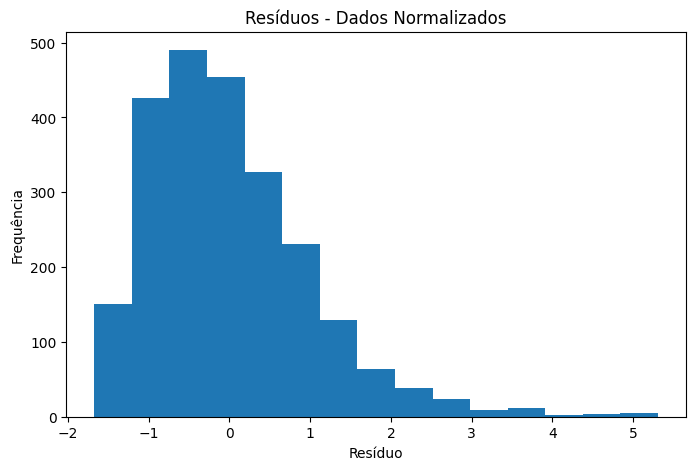

Média dos resíduos (dados originais): 4.038094919546808e-12
Média dos resíduos (dados normalizados): -3.757099914129125e-19


In [25]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Carregar o dataset
df = pd.read_csv("../Dados/dataset1_declarations.csv")

# Converter a coluna da data para formato datetime
df["declaration_date"] = pd.to_datetime(df["declaration_date"])

# Converter colunas para formato numérico
numeric_cols = [
    "gross_salary",
    "side_income_consulting",
    "side_income_board_memberships",
    "assets_in_real_estate",
    "assets_in_vehicles",
    "assets_in_stocks"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remover linhas com valores em falta
df = df.dropna(subset=numeric_cols + ["declaration_date", "agent_id"])

# Ordenar por agente e data
df = df.sort_values(["agent_id", "declaration_date"])

# Selecionar apenas a declaração mais recente de cada agente
recent_df = df.groupby("agent_id").tail(1).copy()

# Calcular o rendimento total
# Calcular o rendimento total
recent_df["total_income"] = (
    recent_df["gross_salary"]
    + recent_df["side_income_consulting"]
    + recent_df["side_income_board_memberships"]
)

# Calcular o património total
recent_df["total_assets"] = (
    recent_df["assets_in_real_estate"]
    + recent_df["assets_in_vehicles"]
    + recent_df["assets_in_stocks"]
)

# Definir variável independente (X) e dependente (y)
X = recent_df[["total_income"]]
y = recent_df["total_assets"]

# Criar e ajustar o modelo de regressão linear
model = LinearRegression()
model.fit(X, y)

# Calcular os valores previstos
predictions = model.predict(X)

# Calcular os resíduos
residuals = y - predictions

# Gráfico dos resíduos nos dados originais
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=15)
plt.title("Resíduos - Dados Originais")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.show()

# Normalizar os dados
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_norm = scaler_x.fit_transform(X)
y_norm = scaler_y.fit_transform(
    y.to_numpy().reshape(-1, 1)
).ravel()

# Criar novo modelo com os dados normalizados
model_norm = LinearRegression()
model_norm.fit(X_norm, y_norm)

# Calcular previsões e resíduos normalizados
pred_norm = model_norm.predict(X_norm)
residuals_norm = y_norm - pred_norm

# Gráfico dos resíduos após normalização
plt.figure(figsize=(8, 5))
plt.hist(residuals_norm, bins=15)
plt.title("Resíduos - Dados Normalizados")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.show()

# Apresentar a média dos resíduos
print("Média dos resíduos (dados originais):", residuals.mean())
print("Média dos resíduos (dados normalizados):", residuals_norm.mean())

### Conclusão US30

A análise dos histogramas mostra que os resíduos se encontram centrados em torno de zero, o que é confirmado pelas médias dos resíduos, que são praticamente nulas tanto nos dados originais como nos dados normalizados. Este resultado indica que o modelo não apresenta enviesamento sistemático nas previsões.

No entanto, observa-se uma assimetria positiva na distribuição dos resíduos, com a presença de alguns valores extremos à direita. Estes casos correspondem a agentes cujo património declarado é significativamente superior ao valor esperado com base nos seus rendimentos declarados, podendo justificar uma análise mais detalhada por parte da Comissão de Ética.

A normalização dos dados não alterou significativamente o padrão dos resíduos, demonstrando que a estrutura do modelo se mantém estável após a transformação das variáveis. Apesar de a regressão linear fornecer uma aproximação razoável da relação entre rendimento e património, a existência de assimetrias e potenciais outliers sugere que outros fatores poderão influenciar a acumulação de património e que modelos mais complexos poderão ser considerados em análises futuras.

## US31

**To be developed**

In [26]:
# Your solution here